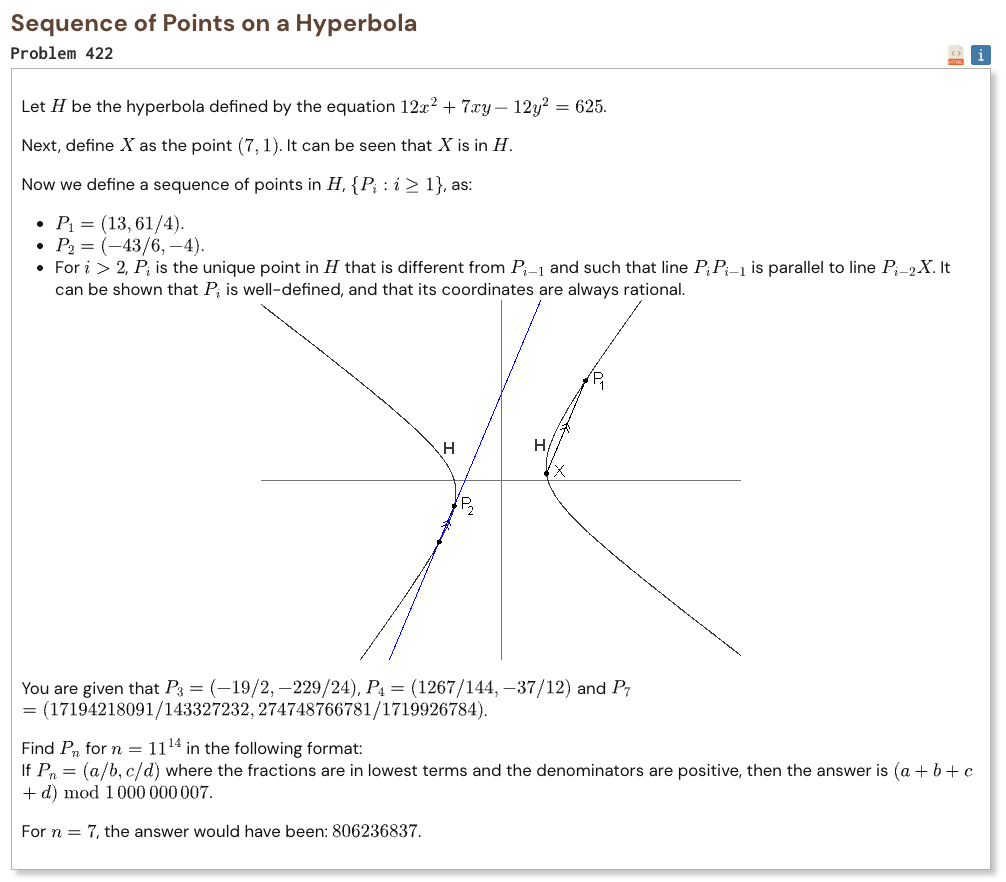

## Initial approach

-   represent every point on the hyperbola using one rational parameter
-   with this parameter the geometric rule becomes a simple recurrence between three consecutive terms
-   the parameter always consists only of powers of two and three
-   track the exponents of two and three instead of storing huge fractions
-   both exponent sequences follow small linear recurrences
-   use fast matrix exponentiation to jump directly to the term at 11^14
-   reduce the exponents modulo one billion and six before calculating the final powers
-   rebuild the numerator and denominator parts and add them modulo one billion and seven

In [1]:
MOD = 1_000_000_007
PHI = MOD - 1


def mat_mul(a, b, mod):
    n = len(a)
    m = len(b[0])
    k = len(b)

    result = [[0] * m for _ in range(n)]

    for i in range(n):
        for t in range(k):
            for j in range(m):
                result[i][j] += a[i][t] * b[t][j]
                result[i][j] %= mod

    return result


def mat_pow(matrix, power, mod):
    size = len(matrix)

    result = [
        [1 if i == j else 0 for j in range(size)]
        for i in range(size)
    ]

    while power > 0:
        if power % 2 == 1:
            result = mat_mul(result, matrix, mod)

        matrix = mat_mul(matrix, matrix, mod)
        power //= 2

    return result


def recurrence_value(n, first, second, constant):
    if n == 1:
        return first % PHI

    if n == 2:
        return second % PHI

    transition = [
        [PHI - 1, 1, constant % PHI],
        [1, 0, 0],
        [0, 0, 1]
    ]

    powered = mat_pow(transition, n - 2, PHI)

    vector = [
        [second % PHI],
        [first % PHI],
        [1]
    ]

    result = mat_mul(powered, vector, PHI)

    return result[0][0]


def solve(n):
    exp_two = recurrence_value(n, 0, 3, 2)
    exp_three = recurrence_value(n, -1, -2, -1)

    q_power = (-exp_two) % PHI
    p_power = exp_three

    p = pow(3, p_power, MOD)
    q = pow(2, q_power, MOD)

    a = (3 * p * p + 4 * q * q) % MOD
    b = (p * q) % MOD

    c = (64 * q * q - 27 * p * p) % MOD
    d = (12 * p * q) % MOD

    return (a + b + c + d) % MOD

In [2]:
%%time
result = solve(11**14)
print("Result:", result)

Result: 92060460
CPU times: user 1.15 ms, sys: 36 μs, total: 1.19 ms
Wall time: 1.16 ms
